In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
#This notebook takes the output from the MAGeCK pipeline and allows you log2 transform the values for each gene of interest and plot as a volcano plot against the P value.

#When you pass the input directory to the function, there is the option to pass lists of genes of interest to the function and visualise them in different colours.


def create_volcano_plots(input_dir, output_dir, magenta_genes, green_genes, black_genes, orange_genes, jitter_strength=0.05, font_size=16):
    # Load the data from a text file
    file_path = f"{input_dir}/20240807_KAT2A_mednorm_allvarest.txt"
    data = pd.read_csv(file_path, sep='\t')
    
    # Specify the columns to plot
    x_column_high = 'lfc_KO_HM_123'
    y_column_high = 'logP_KO_HM_123'
    x_column_low = 'lfc_KO_LM_123'
    y_column_low = 'logP_KO_LM_123'
    
    # Apply 2^lfc transformation for the high and low fractions
    data['exp2_lfc_KO_HM_123'] = 2**data[x_column_high]
    data['exp2_lfc_KO_LM_123'] = 2**data[x_column_low]
    
    # Use p-values directly
    data['logP_KO_HM_123'] = data[y_column_high]
    data['logP_KO_LM_123'] = data[y_column_low]
    
    # Add jitter to avoid overlapping dots
    data['exp2_lfc_KO_HM_123'] += np.random.normal(0, jitter_strength, size=len(data))
    data['exp2_lfc_KO_LM_123'] += np.random.normal(0, jitter_strength, size=len(data))
    
    # Create a figure with two subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
    
    # Plot settings
    plot_settings = [
        ('exp2_lfc_KO_LM_123', 'logP_KO_LM_123', 'KAT2Alow', axes[0]),
        ('exp2_lfc_KO_HM_123', 'logP_KO_HM_123', 'KAT2Ahigh', axes[1])
    ]
    
    # Create the volcano plots
    for x_col, y_col, title, ax in plot_settings:
        if title == 'KAT2Alow':
            # Plot all light grey dots for the KAT2A low population
            sns.scatterplot(x=data[x_col], y=data[y_col], color='#A9A9A9', s=150, ax=ax)
            
            # Highlight specific genes in orange
            subset_orange = data[data['group'].isin(orange_genes)]
            sns.scatterplot(x=subset_orange[x_col], y=subset_orange[y_col], color='orange', s=180, ax=ax, label='Essential genes')
        
        else:
            # Plot light grey dots for the background in KAT2A high population
            sns.scatterplot(x=data[x_col], y=data[y_col], color='#A9A9A9', s=180, ax=ax)
            
            # Highlight magenta for E1/E2 enzymes, light green for E3 enzymes, and black genes
            color_label_map = [
                ('magenta', magenta_genes, 'E1/E2 enzymes'),
                ('#90EE90', green_genes, 'E3 ligase substrate receptors'),  # Light green
                ('black', black_genes, None)  # No label for black genes
            ]
            
            for color, gene_list, label in color_label_map:
                subset = data[data['group'].isin(gene_list)]
                sns.scatterplot(x=subset[x_col], y=subset[y_col], color=color, s=180, ax=ax, label=label if label else None)
        
        # Set plot labels and title with specified font size
        ax.set_xlabel('Fold enrichment', fontsize=font_size)
        ax.set_ylabel('P value', fontsize=font_size)
        ax.set_title(title, fontsize=font_size + 2)
        
        # Set the x-axis to a log2 scale and custom tick marks
        ax.set_xscale('log', base=2)
        ax.set_xticks([1, 4, 16, 64])
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        
        # Set custom x and y limits
        ax.set_xlim(0.5, 40)
        ax.set_ylim(-0.5, 7)

        # Adjust tick label font size
        ax.tick_params(axis='both', which='major', labelsize=font_size - 2)

        # Draw a horizontal line for the p-value threshold
        ax.axhline(y=2, color='black', linestyle='--', linewidth=1)

        # Draw vertical lines for the fold change thresholds
        ax.axvline(x=2, color='black', linestyle='--', linewidth=1)
        ax.axvline(x=1/2, color='black', linestyle='--', linewidth=1)

        # Add legend for labeled genes only for KAT2A high population
        if title == 'KAT2Ahigh' and ax.get_legend():
            ax.legend(fontsize=font_size - 2)

    # Reverse the x-axis for the low fraction
    axes[0].invert_xaxis()

    # Adjust layout and save the plot to a file
    plt.tight_layout()
    plt.savefig(f'{output_dir}/volcano_plot.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{output_dir}/volcano_plot.pdf', dpi=300, bbox_inches='tight')
    plt.show()


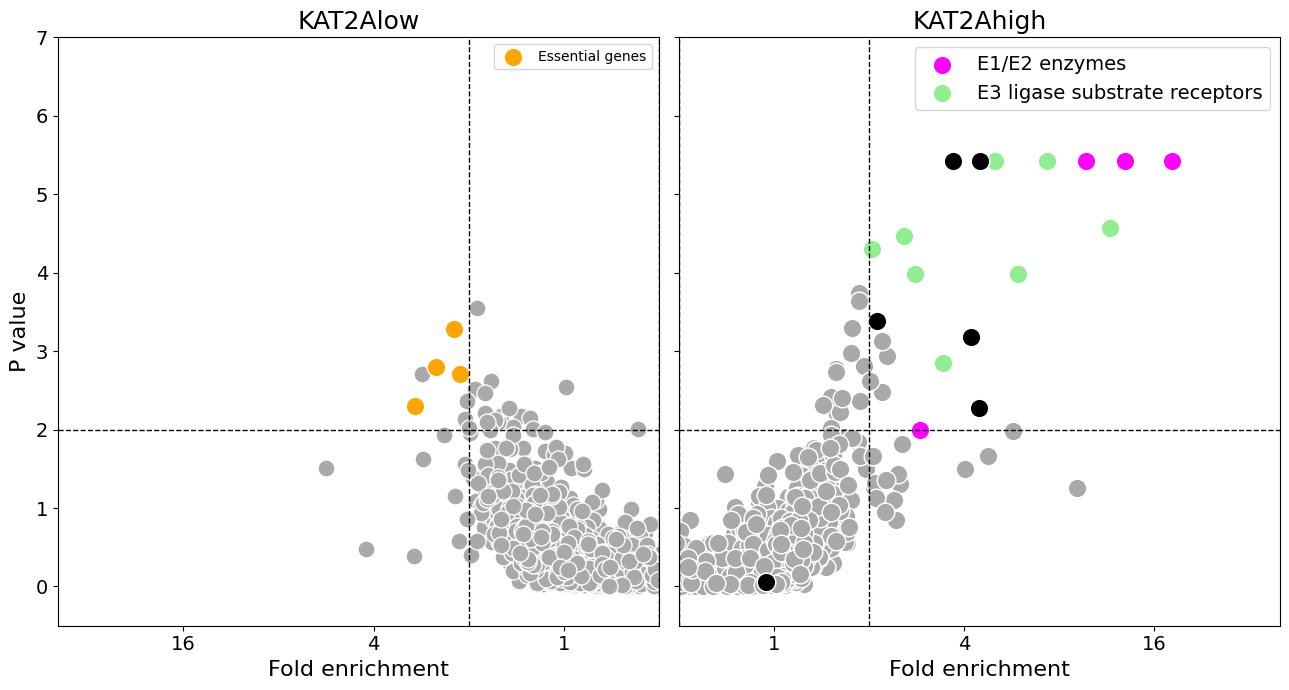

In [ ]:

# Define input and output directories
input_dir = 'input_directory'
output_dir = 'output_directory'

# Specify the labels you want to highlight for each plot
# Pass the jitter size (how well spaced the data points should be) as well as the font size

magenta_genes = ['NAE1', 'UBE2M', 'UBA3', 'UBE2L3']
green_genes = ['UBR5', 'UHRF1', 'SKP2', 'TRAIP', 'ARIH1', 'FBXL5', 'VHL', 'RAE1']
black_genes = ['OTUD5', 'ELOB', 'NUP88', 'NEDD8', 'CUL3', 'USP22']
orange_genes = ['UBE2I', 'RNF181', 'ZBTB39', 'HUWE1']
jitter_strength = 0.05
font_size = 16

# Create the volcano plots
create_volcano_plots(input_dir, output_dir, magenta_genes, green_genes, black_genes, orange_genes, jitter_strength, font_size)
